In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data,
     data.target.rename("HousePrice")],
    axis=1
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print(df.shape)

(20640, 9)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

print("Features and Target Created")

Features and Target Created


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Split Completed")

Data Split Completed


In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

print("Models Created")

Models Created


In [10]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T

results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


In [12]:
best_model = LinearRegression()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [13]:
y_pred = best_model.predict(X_test)

In [14]:
best_model = LinearRegression()

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(
    X_test
)

print("Best Model Trained")

Best Model Trained


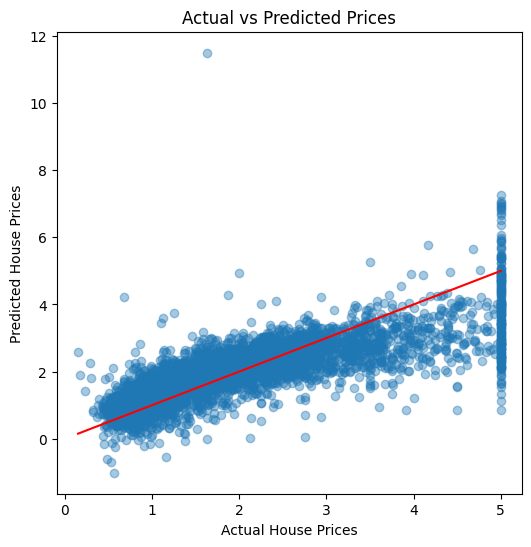

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [16]:
import pickle

pickle.dump(
    best_model,
    open(
        "best_model.pkl",
        "wb"
    )
)

print("Model Saved Successfully")

Model Saved Successfully
